**3D Acoustic Wavefield Simulation Using U-Net Enhanced Fourier Neural Operator**

@author Yang Cui, Uppsala university

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from plotting import plot3d
import random

In [4]:
def read_models(data_root, model_folders, index):
    """Read a binary float32 velocity model (96x96x96)."""
    vp_file = os.path.join(data_root, model_folders[index], "vp3d.bin")
    shape = (96, 96, 96)          # Make sure NX, NY, NZ are defined globally
    vp = np.memmap(vp_file, dtype=np.float32, mode='r', shape=shape)
    return np.array(vp)


def generate_sources(n_train, n_test, nx, ny, nz, pml_width, seed=42):

    margin = pml_width + 5
    rng = np.random.default_rng(seed)
    lo = margin
    hi = [nx - margin, ny - margin, nz - margin]

    n_total = n_train + n_test
    all_locs = rng.integers(low=lo, high=hi, size=(n_total, 3), dtype=np.int32)

    train_locs = all_locs[:n_train]
    test_locs  = all_locs[n_train:]

    return train_locs, test_locs


def plot_source_distribution(vel, train_srcs, test_srcs, save_path=None):
    """
    Visualize training and test source locations
    inside the 3D velocity model.

    Green circles : training sources
    Red stars     : test sources
    """
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    # transparent velocity slices
    nx, ny, nz = vel.shape
    # training sources
    train_srcs = np.array(train_srcs)
    ax.scatter(train_srcs[:, 0], train_srcs[:, 1], train_srcs[:, 2], c='lime', s=120, marker='o', edgecolors='black', linewidths=1.0, depthshade=False, label='Training Sources')
    # test sources
    test_srcs = np.array(test_srcs)
    ax.scatter(test_srcs[:, 0], test_srcs[:, 1], test_srcs[:, 2], c='red', s=300, marker='*', edgecolors='black', linewidths=1.2, depthshade=False, label='Test Sources')
    ax.set_xlim(0, nx)
    ax.set_ylim(0, ny)
    ax.set_zlim(0, nz)
    ax.set_xlabel("X", fontsize=12)
    ax.set_ylabel("Y", fontsize=12)
    ax.set_zlabel("Z", fontsize=12)
    ax.set_title("Sources Distribution", fontsize=12, pad=20)
    ax.legend(loc='upper right', fontsize=12)
    ax.view_init(elev=25, azim=-60)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

In [5]:
## Load data

# vel model
data_root = './'
model_folders = [f'model_{i:04d}' for i in range(100, 200)]
model_index = 2
seed = 202605

# Load snapshot data
label_shot = np.load('./results/ufno_true_snapshots_selected.npy', mmap_mode='r')
pred_shot = np.load('./results/ufno_pred_snapshots_selected.npy', mmap_mode='r')
error_shot = label_shot - pred_shot   # Compute error (difference)

shot_num = 1
time_slice_1 = 5
time_slice_2 = 11

# Load velocity model
vp_np = read_models(data_root, model_folders, model_index)

print(f"Velocity range: {vp_np.min():.1f} – {vp_np.max():.1f} m/s")
print("Label shape:", label_shot.shape)
print("Pred shape: ", pred_shot.shape)


Velocity range: 1834.0 – 4325.9 m/s
Label shape: (2, 20, 96, 96, 96)
Pred shape:  (2, 20, 96, 96, 96)


In [6]:
## generate random sources


n_train = 30
n_test = 5
nx, ny, nz = 96, 96, 96
pml_width = 0

train_sources, test_sources = generate_sources(n_train, n_test, nx, ny, nz, pml_width)

print(f"num of training sources: {len(train_sources)}")
print(f"num of testing sources: {len(test_sources)}")
print(f"the first 3 training sources:\n{train_sources[:3]}")

num of training sources: 30
num of testing sources: 5
the first 3 training sources:
[[12 71 61]
 [42 42 78]
 [12 64 22]]


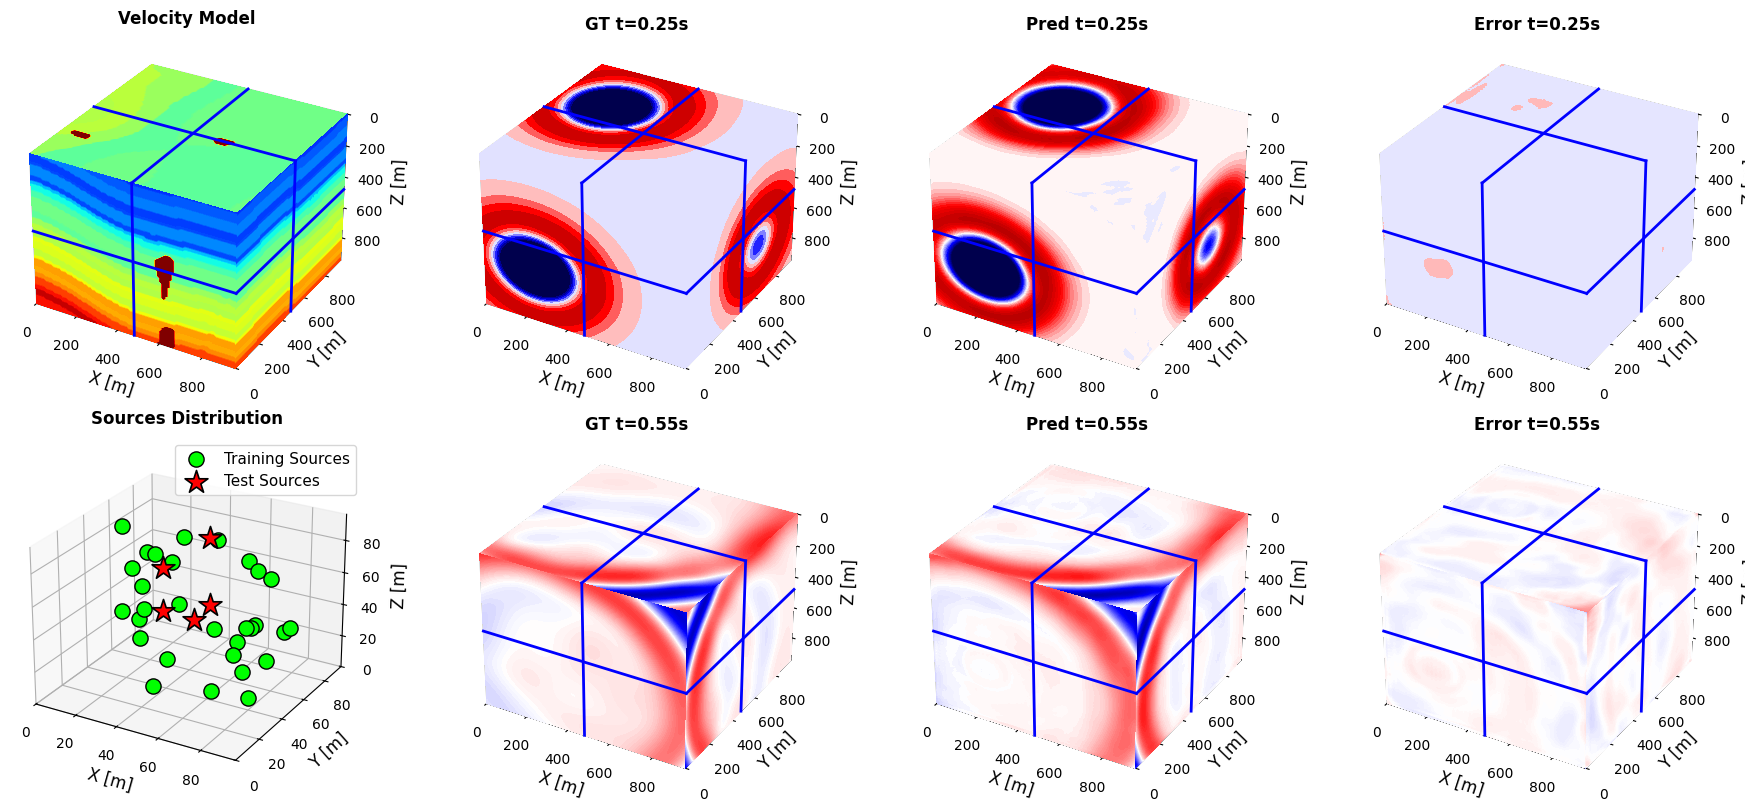

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import string

# 1. Global typography and high-resolution settings
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'figure.dpi': 300
})

# Spatial grid parameters
dx = dy = dz = 10.0
frames = [55, 25, 75]

# 2. Setup Figure (2 rows, 4 columns)
fig, axes = plt.subplots(
    2, 4,
    figsize=(18, 11), 
    subplot_kw={"projection": "3d"}
)
# Explicitly pad hspace to avoid label/title overlaps between rows
fig.subplots_adjust(top=0.95, bottom=0.22, hspace=0.4, wspace=0.1)
axes_flat = axes.flatten()

# 3. Define the structural layout map
# Structure: (Data_Array, Panel_Title, Colormap, vmin, vmax)
plot_items = [
    # ROW 1: Velocity and Wavefield Snapshots at Time 1
    (vp_np.T, "Velocity Model", "jet", 1500, 3500),
    (label_shot[shot_num, time_slice_1, :, :, :], f"GT t={time_slice_1*0.05:.2f}s", "seismic", -0.15, 0.15),
    (pred_shot[shot_num, time_slice_1, :, :, :], f"Pred t={time_slice_1*0.05:.2f}s", "seismic", -0.15, 0.15),
    (error_shot[shot_num, time_slice_1, :, :, :], f"Error t={time_slice_1*0.05:.2f}s", "RdBu", -0.075, 0.075),
    
    # ROW 2: Source Map and Wavefield Snapshots at Time 2
    ("source_dist", "Sources Distribution", None, None, None),
    (label_shot[shot_num, time_slice_2, :, :, :], f"GT t={time_slice_2*0.05:.2f}s", "seismic", -0.15, 0.15),
    (pred_shot[shot_num, time_slice_2, :, :, :], f"Pred t={time_slice_2*0.05:.2f}s", "seismic", -0.15, 0.15),
    (error_shot[shot_num, time_slice_2, :, :, :], f"Error t={time_slice_2*0.05:.2f}s", "RdBu", -0.075, 0.075)
]

alphabet = string.ascii_lowercase
letter_idx = 0

# 4. Processing and Plotting Loop
for idx, item in enumerate(plot_items):
    ax = axes_flat[idx]
    data, title, cmap_name, vmin, vmax = item
    
    plt.sca(ax)
    ax.set_title(title, pad=12)
    
    is_source_plot = isinstance(data, str) and data == "source_dist"

    if is_source_plot:
        # --- Source Distribution Subplot ---
        nx, ny, nz = vp_np.shape
        
        # Transform grid coordinates to physical space (meters)
        tr_coords = np.array(train_sources) * np.array([dx, dy, dz])
        te_coords = np.array(test_sources) * np.array([dx, dy, dz])
        
        ax.scatter(tr_coords[:, 0], tr_coords[:, 1], tr_coords[:, 2],
                   c='lime', s=50, marker='o', edgecolors='black', linewidths=0.8, 
                   depthshade=False, label='Train')
        ax.scatter(te_coords[:, 0], te_coords[:, 1], te_coords[:, 2],
                   c='red', s=180, marker='*', edgecolors='black', linewidths=1.0, 
                   depthshade=False, label='Test')
        
        ax.set_xlim(0, nx * dx)
        ax.set_ylim(0, ny * dy)
        ax.set_zlim(nz * dz, 0) # Depth increasing downwards
        ax.legend(loc='upper right', fontsize=9, markerscale=0.9)
        ax.view_init(elev=25, azim=-60)
        
    else:
        # --- Core 3D Data Subplots ---
        plot3d(
            data, 
            cmap=cmap_name, 
            vmin=vmin, 
            vmax=vmax, 
            dx=dx, dy=dy, dz=dz,
            frames=frames, 
            ifnewfig=False, 
            ifinside=False, 
            showf=False, 
            close=False,
            nlevel=3000
        )

    # Standardized Professional Axis Formatting
    ax.tick_params(labelsize=8, pad=3)
    ax.set_xlabel('X [m]', labelpad=8)
    ax.set_ylabel('Y [m]', labelpad=8)
    ax.set_zlabel('Z [m]', labelpad=8)

    # Clear panel labels anchored to the 2D plane of the subplot
    ax.text2D(0.02, 0.95, f'({alphabet[letter_idx]})', transform=ax.transAxes, 
              fontsize=14, fontweight='normal', va='top', ha='left', zorder=10)
    letter_idx += 1

# 5. Add 3 Horizontal Colorbars at the Base of the Figure
norm_vel   = mcolors.Normalize(vmin=1500, vmax=3500)
norm_wave  = mcolors.Normalize(vmin=-0.15, vmax=0.15)
norm_error = mcolors.Normalize(vmin=-0.075, vmax=0.075)

cbar_width = 0.22
cbar_bottom = 0.15
cbar_height = 0.015

# Colorbar 1: Velocity Model (Columns 1-2 boundary)
cb_ax1 = fig.add_axes([0.12, cbar_bottom, cbar_width, cbar_height])
cb1 = fig.colorbar(cm.ScalarMappable(norm=norm_vel, cmap='jet'), cax=cb_ax1, orientation='horizontal')
cb1.set_label('Velocity [m/s]', labelpad=5)

# Colorbar 2: Wavefield Snapshots (Center)
cb_ax2 = fig.add_axes([0.39, cbar_bottom, cbar_width, cbar_height])
cb2 = fig.colorbar(cm.ScalarMappable(norm=norm_wave, cmap='seismic'), cax=cb_ax2, orientation='horizontal')
cb2.set_label('Wavefield Amplitude', labelpad=5)

# Colorbar 3: Absolute / Structural Error (Columns 3-4 boundary)
cb_ax3 = fig.add_axes([0.66, cbar_bottom, cbar_width, cbar_height])
cb3 = fig.colorbar(cm.ScalarMappable(norm=norm_error, cmap='RdBu'), cax=cb_ax3, orientation='horizontal')
cb3.set_label('Error Amplitude (2x)', labelpad=5)

# Rasterize 3D elements for lightweight vector PDF outputs
for ax in axes.flatten():
    ax.set_rasterized(True)

# Save with tight bounding boxes to prevent clipping
# plt.savefig('./results/figures/ufno_results_comparison_new.pdf', dpi=300, bbox_inches='tight')
plt.show()